In [1]:
# Import necessary libraries
import tensorflow as tf

# Let me load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Check the shapes of the data
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3), Testing labels shape: (10000, 1)


In [2]:
# CIFAR-10 has 10 classes
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("Label names:", label_names)

Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


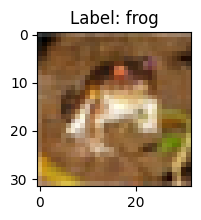

In [3]:
# Plot the image - 0th image in training set along with its label in the title
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(X_train[0])
plt.title(f"Label: {label_names[y_train[0][0]]}")
plt.show()

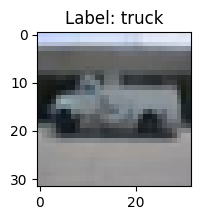

In [4]:
# Plot the image - 110th image in training set along with its label in the title
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(X_train[110])
plt.title(f"Label: {label_names[y_train[110][0]]}")
plt.show()

In [5]:
y_train.shape

(50000, 1)

In [6]:
# Also note over here that the targets are 2D array N x 1 instead of N.
# Therefore, we flatten them.
y_train, y_test = y_train.flatten(), y_test.flatten()
print(y_train.shape)
print(y_test.shape)

(50000,)
(10000,)


In [7]:
# number of classes
K = len(set(y_train))
print("number of classes:", K)

number of classes: 10


In [8]:
# Now lets normalize the pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(32, 32, 3)))


i = Input(shape=(32, 32, 3))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(i) # detect edges
x = BatchNormalization()(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x) # double convo layer for more complex paterns
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)


x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)


x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,397,226 (9.14 MB)

 Trainable params: 2,396,330 (9.14 MB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
# Train the model - 9min 20 secs
r = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test), batch_size=64)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 172ms/step - accuracy: 0.4414 - loss: 1.8186 - val_accuracy: 0.6544 - val_loss: 0.9944
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 130s 166ms/step - accuracy: 0.6915 - loss: 0.8789 - val_accuracy: 0.7071 - val_loss: 0.8745
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 120s 153ms/step - accuracy: 0.7691 - loss: 0.6654 - val_accuracy: 0.7122 - val_loss: 0.8322
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 123s 157ms/step - accuracy: 0.8012 - loss: 0.5646 - val_accuracy: 0.7669 - val_loss: 0.7006
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 126s 161ms/step - accuracy: 0.8393 - loss: 0.4631 - val_accuracy: 0.7964 - val_loss: 0.6350
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 118s 151ms/step - accuracy: 0.8697 - loss: 0.3749 - val_accuracy: 0.8092 - val_loss: 0.5910
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 117s 149ms/step - accuracy: 0.8951 - loss: 0.3025 - val_accuracy: 0.7814 - val_loss: 0.7073
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 129s 165ms/step - accuracy: 0.9056 -

In [13]:
/batch_size = 32
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10, # Randomly rotate images in the range (degrees, 0 to 180). 10 means rotate between -10 to +10 degrees
    width_shift_range=0.1, # Randomly shift images horizontally (fraction of total width). 0.1 means shift by 10% of the total width
    height_shift_range=0.1, # Randomly shift images vertically (fraction of total height). 0.1 means shift by 10% of the total height
    horizontal_flip=True, # Randomly flip images horizontally
    zoom_range=0.1 # Randomly zoom into images. 0.1 means zoom in by 10%
)
# This will create an iterator that will generate batches of augmented images and their corresponding labels on the fly during training
# The total number of  images generated will be equal to the number of batches per epoch (which is total number of training samples divided by batch size) multiplied by the number of epochs. So if we have 50000 training samples and batch size is 32, then we will have 1563 batches per epoch. If we train for 50 epochs, then we will have 1563 * 50 = 78150 augmented images generated during training.
train_generator = data_generator.flow(X_train, y_train, batch_size=batch_size)
steps_per_epoch = len(X_train) // batch_size
r = model.fit(train_generator, epochs=5, validation_data=(X_test, y_test), steps_per_epoch=steps_per_epoch)


SyntaxError: invalid syntax (3245882375.py, line 1)

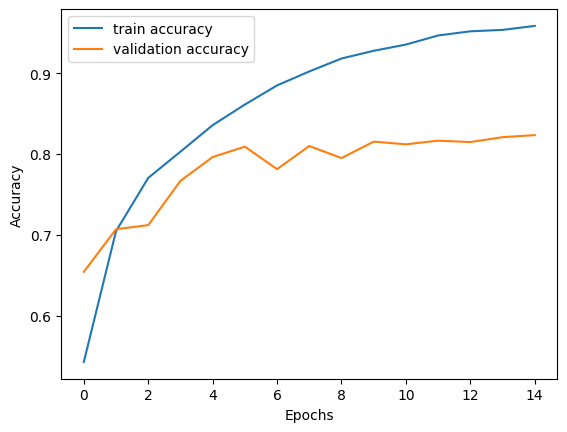

In [14]:
# Plot the accuracy and validation accuracy per epoch
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

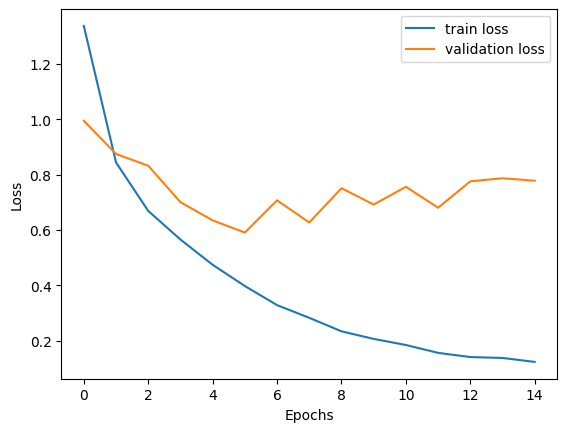

In [15]:
# Plot the loss and validation loss per epoch
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
import numpy as np
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


array([3, 8, 8, ..., 5, 1, 7])

In [17]:
y_pred.shape

(10000,)

In [ ]:
y_test.shape

In [18]:
# Lets look at the confusion matrix with True labels on x-axis and Predicted labels on y-axis
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

ModuleNotFoundError: No module named 'sklearn'

In [19]:
# Find the indices where predictions are incorrect
misclassified_indices = np.where(y_test.flatten() != y_pred)[0]
misclassified_indices

array([   6,    9,   22, ..., 9983, 9995, 9996])

In [20]:
# Print the total number of misclassified images
print(f'Total misclassified images: {len(misclassified_indices)}')

Total misclassified images: 1765


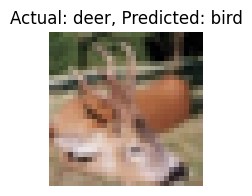

In [21]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

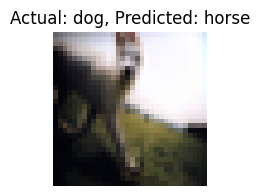

In [22]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

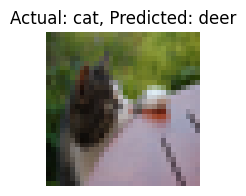

In [23]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

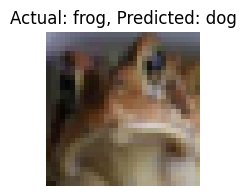

In [24]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()